
# **Skill-Luck Decomposition via Linear Combination Code**
# Main code block: does calculations for q

In [19]:
# ============================================================
# Skill–Luck Decomposition (fixed schemas using `league`)
# ============================================================

import pandas as pd
import numpy as np

# ------------------------- INPUTS ---------------------------
# Spearman (use spearman_r, not spearman_p)
SPEARMAN_SKILL = "/mnt/data/us_combined_spearman_pure_skill.csv"
SPEARMAN_LUCK  = "/mnt/data/us_combined_spearman_coinflip_0.5.csv"
SPEARMAN_REAL  = "/mnt/data/us_combined_spearman.csv"

# Upset frequency (already aggregated to season-level)
UPSET_REAL_AGG  = "/mnt/data/us_combined_upset_frequency.csv"
UPSET_SKILL_AGG = "/mnt/data/us_pure_skill_upset_frequency.csv"
UPSET_LUCK_AGG  = "/mnt/data/us_coinflip_0.5_upset_frequency.csv"

# Output
OUTPUT_CSV = "/mnt/data/skill_luck_decomposition.csv"
CLAMP_0_1 = False  # set True if you want q clamped to [0,1] in the saved CSV

# 1. Helper: Load in the spearman files

def load_spearman_minimal(path):
    """
    Expect columns: league, season, spearman_r
    Returns: league, season, metric_value (from spearman_r)
    """
    df = pd.read_csv(path, usecols=["league", "season", "spearman_r"])
    out = df.rename(columns={"spearman_r": "metric_value"})
    return out[["league", "season", "metric_value"]]


# 2. Helper: Load in the upset frequency files

def load_upset_agg_minimal(path):
    """
    Expect columns: league, season, upset_frequency
    Returns: league, season, metric_value (from upset_frequency)
    """
    df = pd.read_csv(path, usecols=["league", "season", "upset_frequency"])
    out = df.rename(columns={"upset_frequency": "metric_value"})
    return out[["league", "season", "metric_value"]]

# 3. Helper: Compute q = (real - luck) / (skill - luck) per (league, season).

def compute_q(metric_name, df_skill, df_luck, df_real, clamp=CLAMP_0_1):
    merged = (
        df_real.merge(df_skill, on=["league","season"], how="outer", suffixes=("_real","_skill"))
               .merge(df_luck,  on=["league","season"], how="outer")
               .rename(columns={
                   "metric_value": "metric_luck",
                   "metric_value_real": "metric_real",
                   "metric_value_skill": "metric_skill"
               })
    )


    denom = merged["metric_skill"] - merged["metric_luck"]  # define denominator
    with np.errstate(divide='ignore', invalid='ignore'):
        q = (merged["metric_real"] - merged["metric_luck"]) / denom # define q
    q = q.where(~np.isclose(denom, 0.0), np.nan)

    if clamp: # clamp to be between 0 and 1 if wanted
        q = q.clip(0, 1)

    merged["metric_name"] = metric_name
    merged["q_skill"] = q
    merged["luck_share"] = 1 - q # define luck_share = 1 - q

    return merged[[
        "league","season","metric_name",
        "metric_real","metric_skill","metric_luck",
        "q_skill","luck_share"
    ]]

# 4. Compute q for spearman:

sp_skill = load_spearman_minimal(SPEARMAN_SKILL)
sp_luck  = load_spearman_minimal(SPEARMAN_LUCK)
sp_real  = load_spearman_minimal(SPEARMAN_REAL)

spearman_out = compute_q("spearman_r", sp_skill, sp_luck, sp_real)

# 5. Compute q for upset frequency:

up_skill = load_upset_agg_minimal(UPSET_SKILL_AGG)
up_luck  = load_upset_agg_minimal(UPSET_LUCK_AGG)
up_real  = load_upset_agg_minimal(UPSET_REAL_AGG)

upset_out = compute_q("upset_frequency", up_skill, up_luck, up_real)

# 6. Combine and save results:

results = pd.concat([spearman_out, upset_out], ignore_index=True)
results.to_csv(OUTPUT_CSV, index=False)
print(f"Saved: {OUTPUT_CSV}")
print(results.head(10))


Saved: /mnt/data/skill_luck_decomposition.csv
  league  season metric_name  metric_real  metric_skill  metric_luck  \
0    MLB    1980  spearman_r     0.663407      0.955309    -0.045361   
1    MLB    1981  spearman_r     0.426272      0.912103     0.268013   
2    MLB    1982  spearman_r     0.373448      0.958048     0.177250   
3    MLB    1983  spearman_r     0.392220      0.957348    -0.143989   
4    MLB    1984  spearman_r     0.223845      0.920021    -0.140692   
5    MLB    1985  spearman_r     0.644958      0.940895     0.332819   
6    MLB    1986  spearman_r     0.209586      0.945168    -0.277558   
7    MLB    1987  spearman_r     0.375258      0.979805     0.199617   
8    MLB    1988  spearman_r     0.449211      0.958747     0.199450   
9    MLB    1989  spearman_r     0.444693      0.943817    -0.198865   

    q_skill  luck_share  
0  0.708294    0.291706  
1  0.245709    0.754291  
2  0.251279    0.748721  
3  0.486871    0.513129  
4  0.343672    0.656328  
5  0.

# Visualizations Code Block

Clamped 20 rows to [0,1] for visualization.


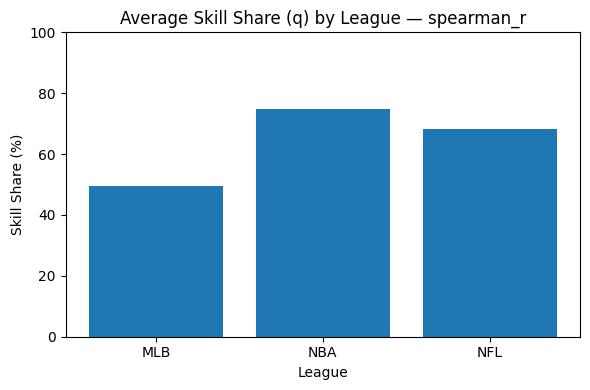

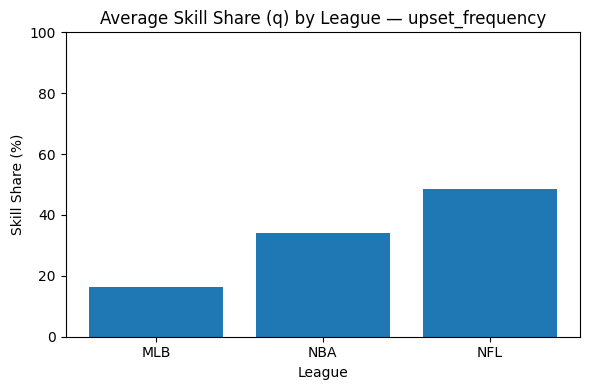

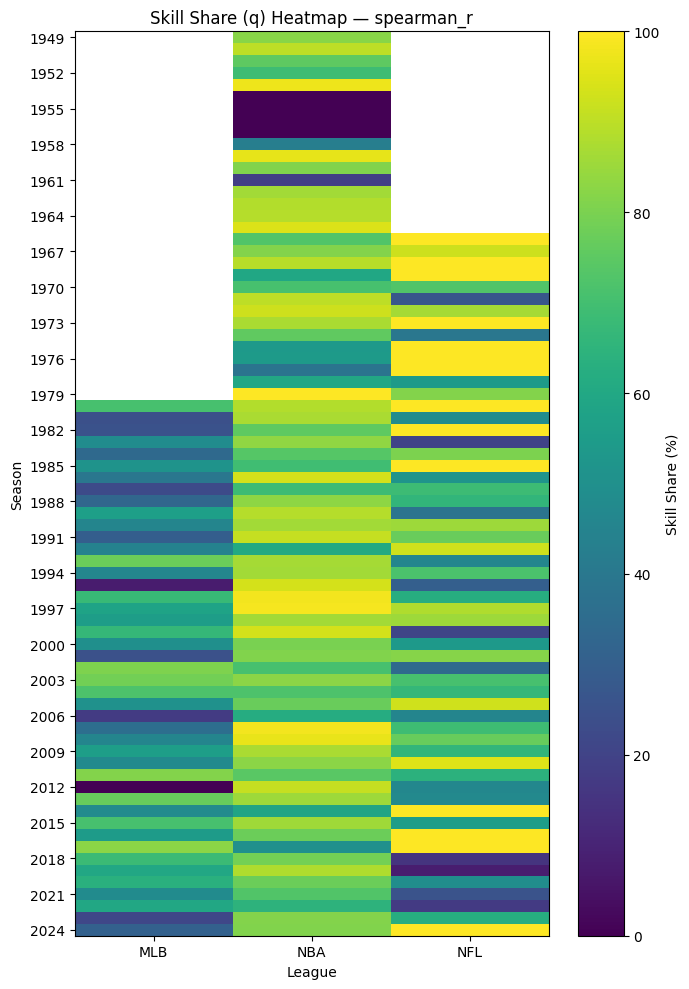

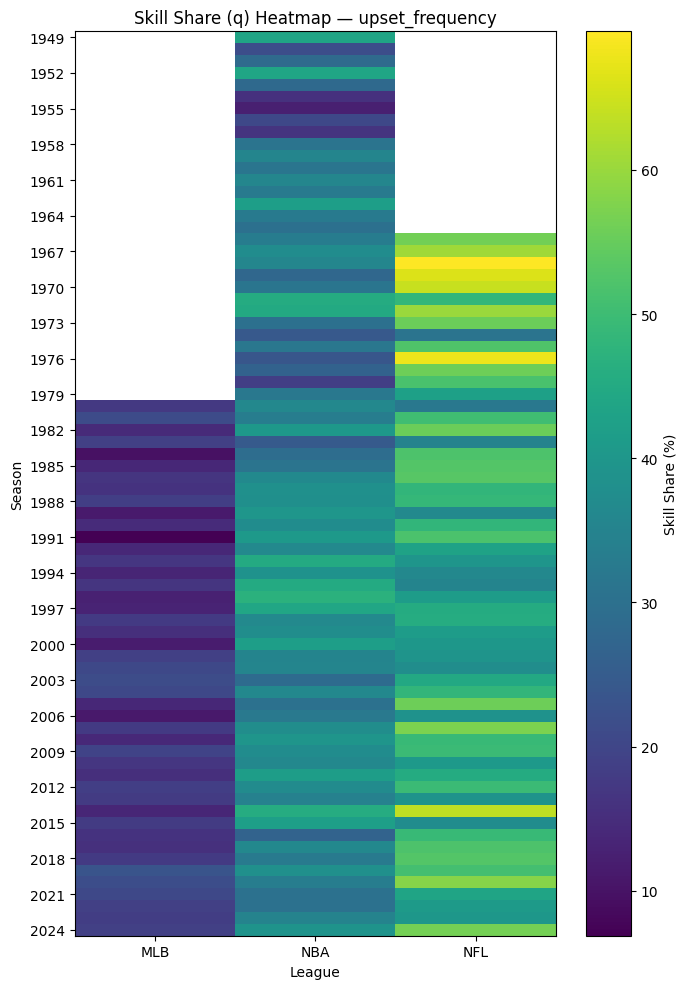

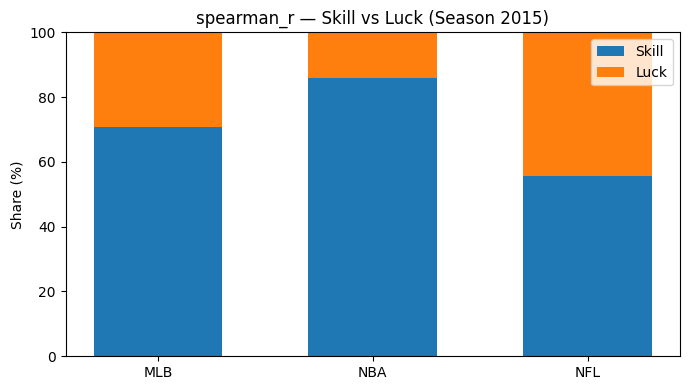

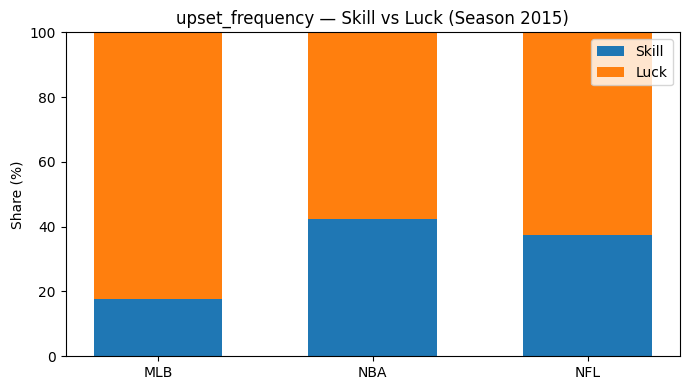


Average skill share (q, CLAMPED) by metric and league:
    metric_name league  q_skill_mean  q_skill_mean_pct
     spearman_r    MLB      0.495690              49.6
     spearman_r    NBA      0.748328              74.8
     spearman_r    NFL      0.683056              68.3
upset_frequency    MLB      0.163999              16.4
upset_frequency    NBA      0.341481              34.1
upset_frequency    NFL      0.484097              48.4


In [18]:
# Visualizations from skill luck decomposition
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, glob

# 1. Inputs / Outputs
CSV_PATH   = "/mnt/data/skill_luck_decomposition.csv"
CLAMP_Q_01 = True      # clamp q to [0,1] for visuals/summary
OUT_DIR    = "/mnt/data/skill_luck_figs"

# 2. Load in files
if not os.path.exists(CSV_PATH):
    print("File not found:", CSV_PATH)
    print("Here are CSVs under /mnt/data:")
    for p in sorted(glob.glob("/mnt/data/*.csv")):
        print(" -", p)
    raise SystemExit

df = pd.read_csv(CSV_PATH)

# 3. Check column names
required = ["league","metric_name","q_skill"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df["league"] = df["league"].astype(str).str.upper().str.strip()
if "season" in df.columns:
    df["season"] = pd.to_numeric(df["season"], errors="coerce")
df["q_skill"] = pd.to_numeric(df["q_skill"], errors="coerce")
if "luck_share" not in df.columns:
    df["luck_share"] = 1 - df["q_skill"]

# 4. Clamp values to be in [0,1] (to make sense visually)
if CLAMP_Q_01:
    df["q_skill_clamped"] = df["q_skill"].clip(0, 1)
    df["luck_share_clamped"] = 1 - df["q_skill_clamped"]
    df["q_was_clamped"] = (df["q_skill"] != df["q_skill_clamped"])
    print(f"Clamped {int(df['q_was_clamped'].sum())} rows to [0,1] for visualization.")
else:
    df["q_skill_clamped"] = df["q_skill"]
    df["luck_share_clamped"] = df["luck_share"]
    df["q_was_clamped"] = False


# 5. Bar charts: average q by league for each metric
metrics = sorted(df["metric_name"].dropna().unique())
for metric in metrics:
    sub = df[df["metric_name"] == metric]
    bar_data = (
        sub.groupby("league", as_index=False)["q_skill_clamped"]
           .mean()
           .sort_values("league")
    )
    plt.figure(figsize=(6,4))
    plt.bar(bar_data["league"], bar_data["q_skill_clamped"]*100)
    plt.title(f"Average Skill Share (q) by League — {metric}")
    plt.xlabel("League")
    plt.ylabel("Skill Share (%)")
    plt.ylim(0, 100)
    plt.tight_layout()
    plt.show()

# 6. Heatmaps: q across seasons (rows) and leagues (cols) for each metric
has_season = "season" in df.columns and df["season"].notna().any()
if has_season:
    for metric in metrics:
        sub = df[df["metric_name"] == metric]
        if sub["season"].notna().any():
            piv = (
                sub.pivot_table(index="season", columns="league",
                                values="q_skill_clamped", aggfunc="mean")
                   .sort_index()
            )
            M = piv.to_numpy()
            if np.isnan(M).all():
                continue

            fig_h = max(3, min(10, 0.4*len(piv.index)+2))
            plt.figure(figsize=(7, fig_h))
            ax = plt.gca()
            im = ax.imshow(M*100, aspect="auto", interpolation="nearest")
            ax.set_title(f"Skill Share (q) Heatmap — {metric}")
            ax.set_xlabel("League")
            ax.set_ylabel("Season")

            ax.set_xticks(np.arange(len(piv.columns)))
            ax.set_xticklabels(piv.columns.tolist())
            seasons = piv.index.values
            if len(seasons) > 25:
                step = max(1, len(seasons)//25)
                idxs = np.arange(0, len(seasons), step)
                ax.set_yticks(idxs)
                ax.set_yticklabels(seasons[idxs].astype(int))
            else:
                ax.set_yticks(np.arange(len(seasons)))
                ax.set_yticklabels(seasons.astype(int))

            cbar = plt.colorbar(im)
            cbar.set_label("Skill Share (%)")
            plt.tight_layout()
            plt.show()


# 7. Stacked bars (skill vs luck) for a specific season per metric
SELECTED_SEASON = 2015  # change this to any season
if has_season:
    for metric in metrics:
        sub = df[df["metric_name"] == metric]

        # filter to selected_season
        sub_year = sub[sub["season"] == SELECTED_SEASON]

        # if no data for that season for that league, output no data
        if sub_year.empty:
            print(f"[{metric}] No data for season {SELECTED_SEASON}. Skipping.")
            continue

        block = (
            sub_year
            .groupby("league", as_index=False)[["q_skill_clamped","luck_share_clamped"]]
            .mean()
            .sort_values("league")
        )

        x = np.arange(len(block["league"]))
        width = 0.6

        plt.figure(figsize=(7,4))
        plt.bar(x, block["q_skill_clamped"]*100, width, label="Skill")
        plt.bar(x, block["luck_share_clamped"]*100, width,
                bottom=block["q_skill_clamped"]*100, label="Luck")
        plt.xticks(x, block["league"])
        plt.ylim(0, 100)
        plt.title(f"{metric} — Skill vs Luck (Season {SELECTED_SEASON})")
        plt.ylabel("Share (%)")
        plt.legend()
        plt.tight_layout()
        plt.show()


# 8. Summary of values
summary = (
    df.groupby(["metric_name","league"], as_index=False)["q_skill_clamped"]
      .mean()
      .rename(columns={"q_skill_clamped":"q_skill_mean"})
)
summary["q_skill_mean_pct"] = (summary["q_skill_mean"]*100).round(1)
print("\nAverage skill share (q, CLAMPED) by metric and league:")
print(summary.sort_values(["metric_name","league"]).to_string(index=False))
